<a href="https://colab.research.google.com/github/MariiaYarmolenko/HW-Data-Loves/blob/main/HW_11.3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [44]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

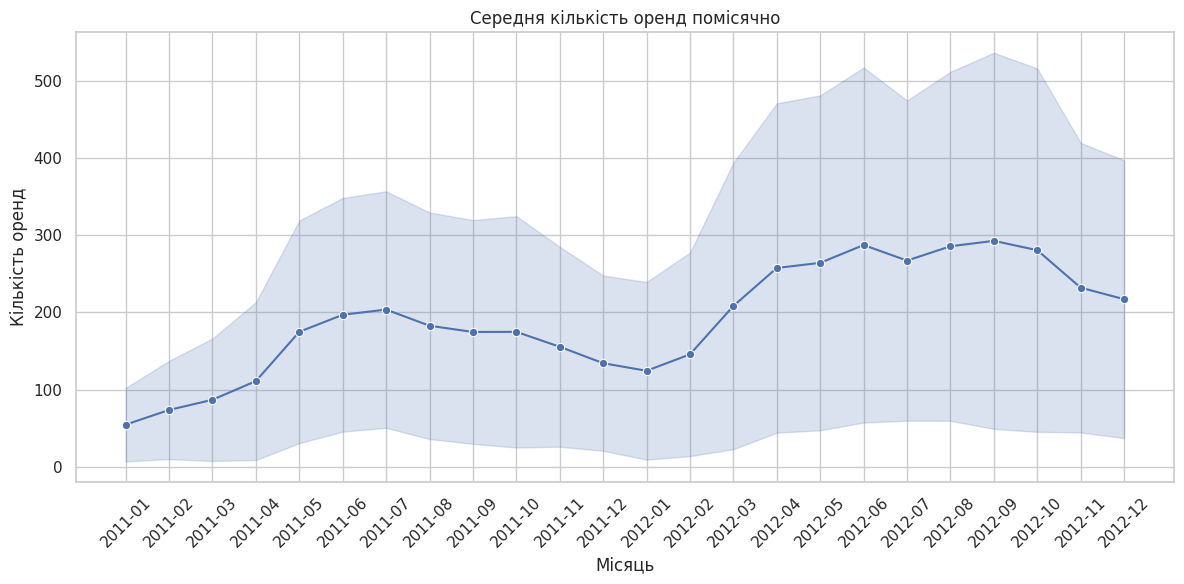

In [45]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    marker='o',
    x='month_year',
    y='count',
    errorbar=('sd', 1)
)

plt.title('Середня кількість оренд помісячно')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренд')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Найбільша невизначеність даних припадає на вересень, жовтень, серпень та червень 2012 року. Можна припустити, що це пов'язане зі зростанням попиту у другий рік, а також з піковістю попиту саме в ці місяці щорічно. Тобто, маючи пік в ці місяці, на розкид даних буде впливати велика кількість факторів: день тижня, погода в конкретні дні, наявність свят, тоді як в періоди з меншим попитом дані згруповані навколо нижчих значень і не мають такого вираженого впливу.

In [46]:
deviation_check = df.groupby('month')['count'].std()

print(deviation_check.sort_values(ascending=False))

month
9     208.915910
10    204.079411
6     199.628690
8     197.198461
5     189.320173
7     184.857337
4     182.417619
11    165.420965
12    155.926050
3     155.352814
2     109.802322
1      95.302518
Name: count, dtype: float64


## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

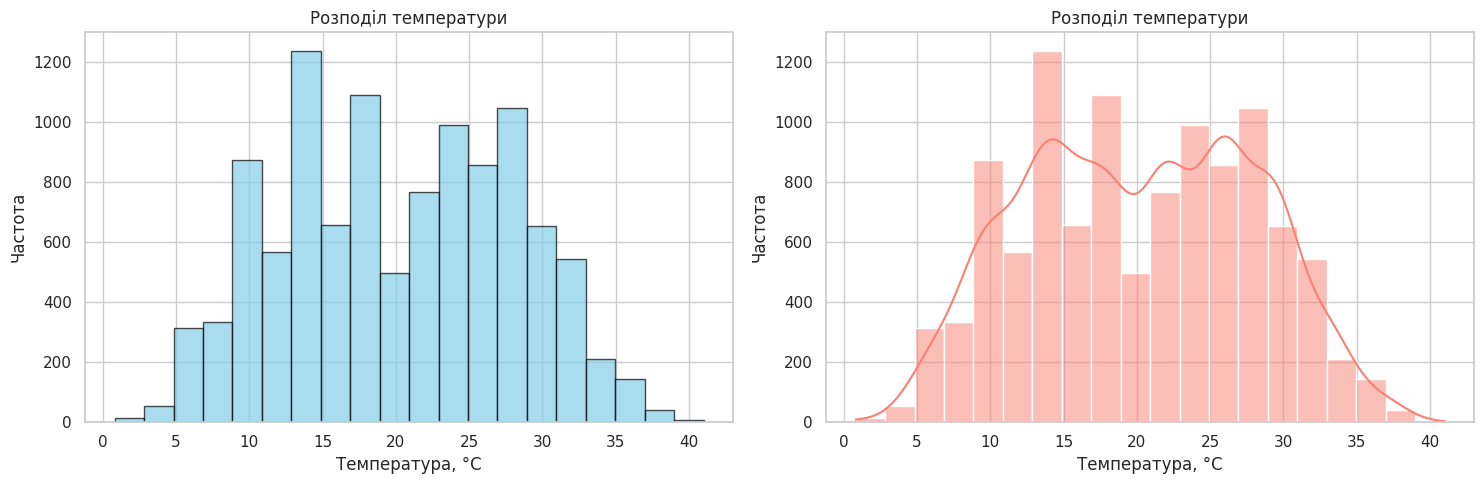

In [47]:
num_bins = 20
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df['temp'].plot.hist(
    bins=num_bins,
    alpha=0.7,
    ax=axes[0],
    color='skyblue',
    edgecolor='black',
    title='Розподіл температури',
    xlabel='Температура, °C',
    ylabel='Частота'
)

sns.histplot(df['temp'],
    bins=num_bins,
    kde=True,
    ax=axes[1],
    color='salmon'
)

axes[1].set_title('Розподіл температури')
axes[1].set_xlabel('Температура, °C')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

1. При побудові гістограми з використанням Pandas графік виглядає більш "грубо" та менш естетично, оскільки Pandas створений для швидкого підрахунку, та обмежений у глибшому аналізі, наприклад ми не можемо створити KDE або зафарбувати окремі категорії без створення циклу.

Seaborn створений для естетичного відображення статистичних показників і дає можливість поглибленого аналізу, наприклад KDE, що є "фішкою" Seaborn, дозволяє оцінити щільність розподілу даних, також зафарбовування за певними групами можливе завдяки всього одній функції - hue. Колірна палітра, шрифти, розмітка - все оптимізовано у цій бібліотеці.

2. KDE (Kernel Density Estimate) - це крива (оцінка щільності ядра) набагато краще візуалізує розподіл даних, допомагаючи побачити тренди, які можуть бути приховані через випадковий вибір ширини стовпчиків (бінів). Завжди краще використовувати kde=True, коли працюємо з неперервними величинами (як температура). Це дозволяє побачити, чи є розподіл нормальним, чи, можливо, він має кілька піків (бі- або мультимодальний), що може вказувати на певні закономірності в даних (наприклад, різні робочі зміни або сезони).

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

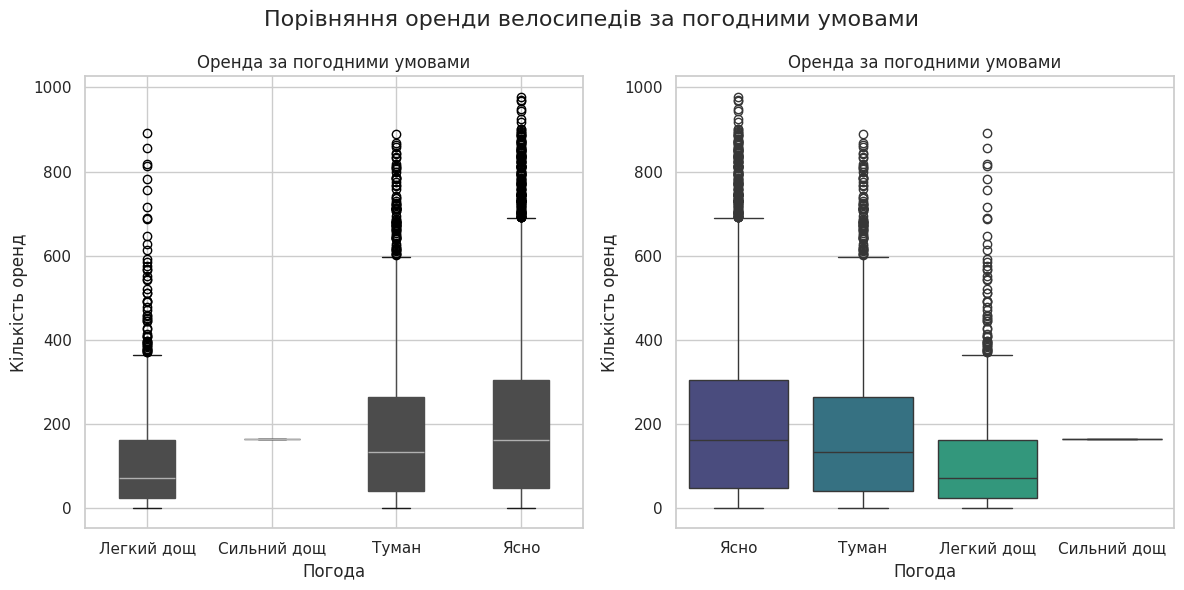

In [48]:
weather_names = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

df['weather_names'] = df['weather'].map(weather_names)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

df.boxplot(
    column='count',
    by='weather_names',
    ax=axes[0],
    patch_artist=True
)

axes[0].set_title('Оренда за погодними умовами')
axes[0].set_xlabel('Погода')
axes[0].set_ylabel('Кількість оренд')

sns.boxplot(
    data=df,
    x='weather_names',
    y='count',
    hue='weather_names',
    legend=False,
    ax=axes[1],
    palette='viridis'
)

axes[1].set_title('Оренда за погодними умовами')
axes[1].set_xlabel('Погода')
axes[1].set_ylabel('Кількість оренд')

plt.suptitle('Порівняння оренди велосипедів за погодними умовами', fontsize=16)
plt.tight_layout()
plt.show()

Pandas вимагає складних маніпуляцій з індексами та мітками осей (xticklabels), щоб категорії відображалися у певному логічному порядку, а не за алфавітом.

Seaborn iдеально працює з pandas DataFrame. Він автоматично підхоплює назви категорій і сам вибудовує графіки в потрібній послідовності.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


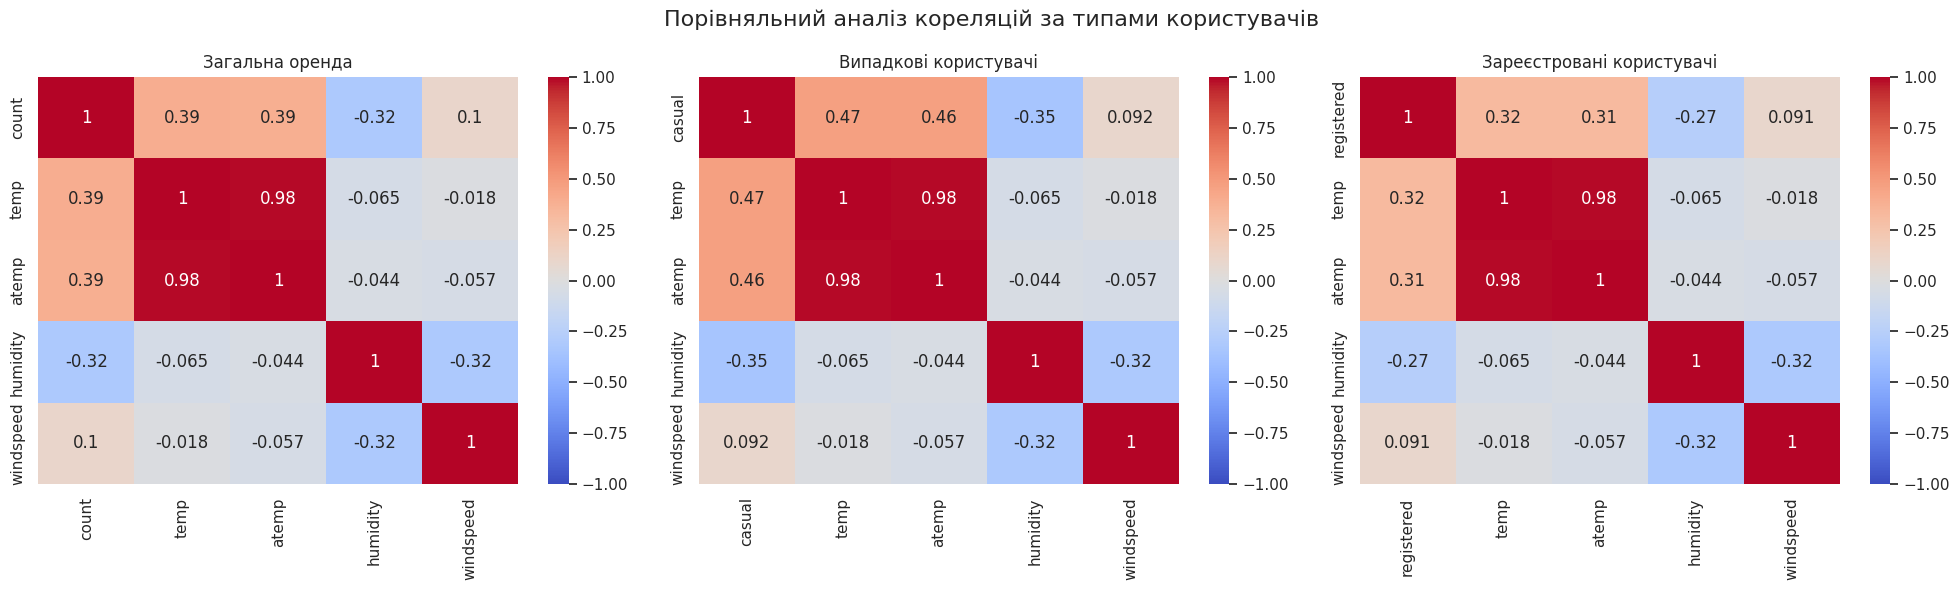

In [49]:
#Так довго це робила, а виявилось зовсім не зручно 😀

corr_count = ['count', 'temp', 'atemp', 'humidity', 'windspeed']
corr_casual = ['casual', 'temp', 'atemp', 'humidity', 'windspeed']
corr_registered = ['registered', 'temp', 'atemp', 'humidity', 'windspeed']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

groups = [corr_count, corr_casual, corr_registered]
titles = ['Загальна оренда', 'Випадкові користувачі', 'Зареєстровані користувачі']

for i in range(3):
      corr_matrix = df[groups[i]].corr()
      sns.heatmap(
          corr_matrix,
          ax=axes[i],
          annot=True,
          cmap='coolwarm',
          vmin=-1,
          vmax=1
      )
      axes[i].set_title(titles[i])

plt.suptitle('Порівняльний аналіз кореляцій за типами користувачів', fontsize=16)
plt.tight_layout()
plt.show()

1. Змінні, що найсильніше корелюють з загальною кількістю оренди (count)

Температура (temp) та відчутна температура (atemp). Обидві мають коефіцієнт кореляції 0.39. Це свідчить про те, що зі зростанням температури кількість оренд велосипедів помітно збільшується.

Швидкість вітру (windspeed) має слабку позитивну кореляцію (0.1), а вологість (humidity) - негативну (-0.32).

2. Кореляція між temp та atemp

Між температурою (temp) та відчутною температурою (atemp) спостерігається надзвичайно висока кореляція - 0.98.
Це пояснюється тим, що ці змінні математично залежні. atemp (відчутна температура) розраховується на основі фактичної температури повітря temp з урахуванням інших факторів, таких як вологість та швидкість вітру. Тому вони практично завжди змінюються синхронно.

3. Змінні з негативною кореляцією та причини
humidity (вологість) з показником -0.32.
Це цілком логічно з точки зору поведінки користувачів: висока вологість часто супроводжується туманом, дощем або просто некомфортними умовами для поїздки на велосипеді.

Також варто зазначити, що humidity має від'ємну кореляцію зі швидкістю вітру (-0.32), що вказує на певні погодні закономірності в даному датасеті, але це потребує додаткових досліджень.

4. Аналіз зареєстрованих та випадкових користувачів

Випадкові користувачі (casual) мають вищу кореляцію з температурою (0.47), ніж зареєстровані (registered) (0.32). Це підтверджує, що для випадкових клієнтів комфортна погода є головним драйвером для поїздки.

Зареєстровані користувачі є більш "стійкими" - вони орендують велосипеди навіть при менш сприятливих умовах, бо використовують їх як регулярний транспорт (наприклад, поїздки на роботу).

Вологість негативно впливає на обидві групи (кореляція -0.35 та -0.27), але випадкові користувачі знову ж таки виявляються більш чутливими до підвищеної вологості.

Вітер має мінімальний вплив на обидві групи (кореляція близька до нуля), що може бути цікавим фактом для бізнесу - вітер не є суттєвим бар'єром для оренди.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


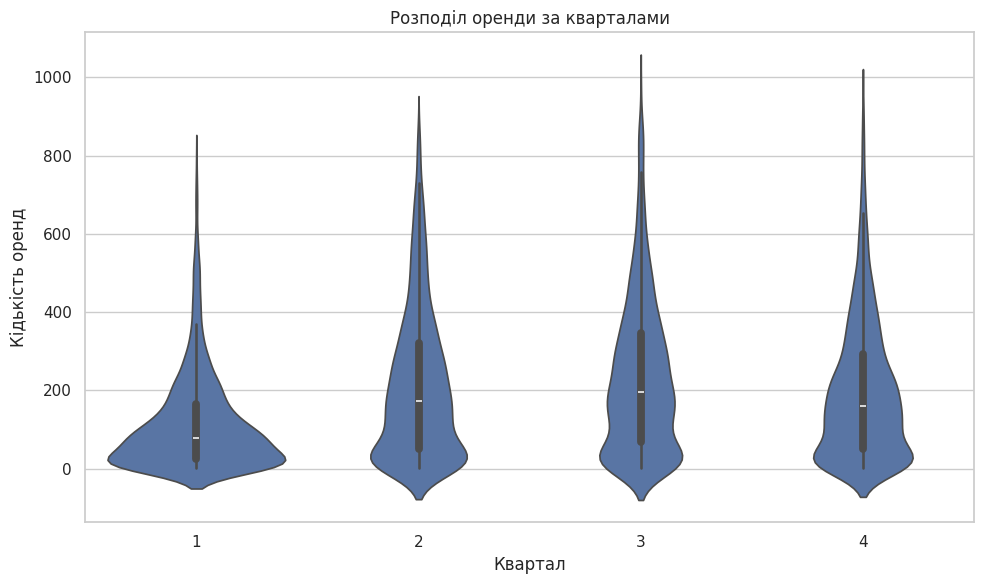

In [50]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='season', y='count')
plt.title('Розподіл оренди за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кідькість оренд')
plt.tight_layout()
plt.show()

1. "Товщина" (ширина) violin plot у кожній точці показує щільність розподілу даних (Kernel Density Estimation).
Широкі ділянки графіка вказують на те, в цьому діапазоні значень зосереджена найбільша кількість спостережень (найчастіша кількість оренд).

2. Найбільша варіабельність спостерігається у 3-му кварталі, оскільки "скрипка" для 3 кварталу має найбільший вертикальний розмах і найширший діапазон значень.

3. Головна перевага полягає в деталізації розподілу:
Box plot показує лише основні статистичні показники: медіану, квартилі та викиди.
Violin plot поєднує в собі інформативність box plot (всередині "скрипки" часто відображений сам box plot) і показує форму розподілу як гістограма (чи є він одномодальним, чи має кілька піків).

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

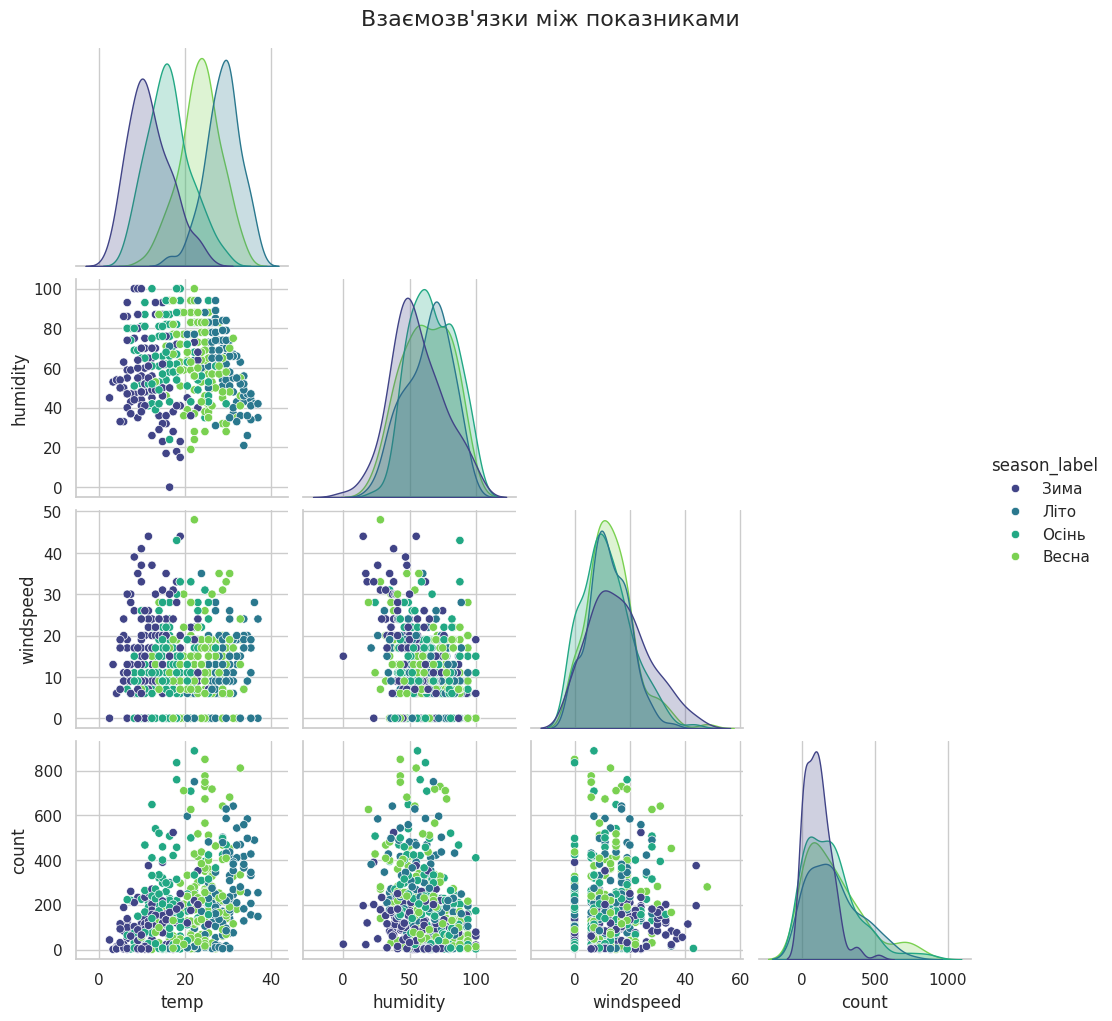

In [65]:
season_map = {1: 'Зима', 2: 'Весна', 3: 'Літо', 4: 'Осінь'}

df_viz = df.copy()
df_viz['season_label'] = df_viz['season'].map(season_map)

data_pairplot = sns.pairplot(
    data=df_viz.sample(500),
    vars=['temp', 'humidity', 'windspeed', 'count'],
    hue='season_label',
    palette='viridis',
    corner=True,
    diag_kind='kde'
)

data_pairplot.fig.suptitle('Взаємозв\'язки між показниками', y=1.02, fontsize=16)
plt.show()

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

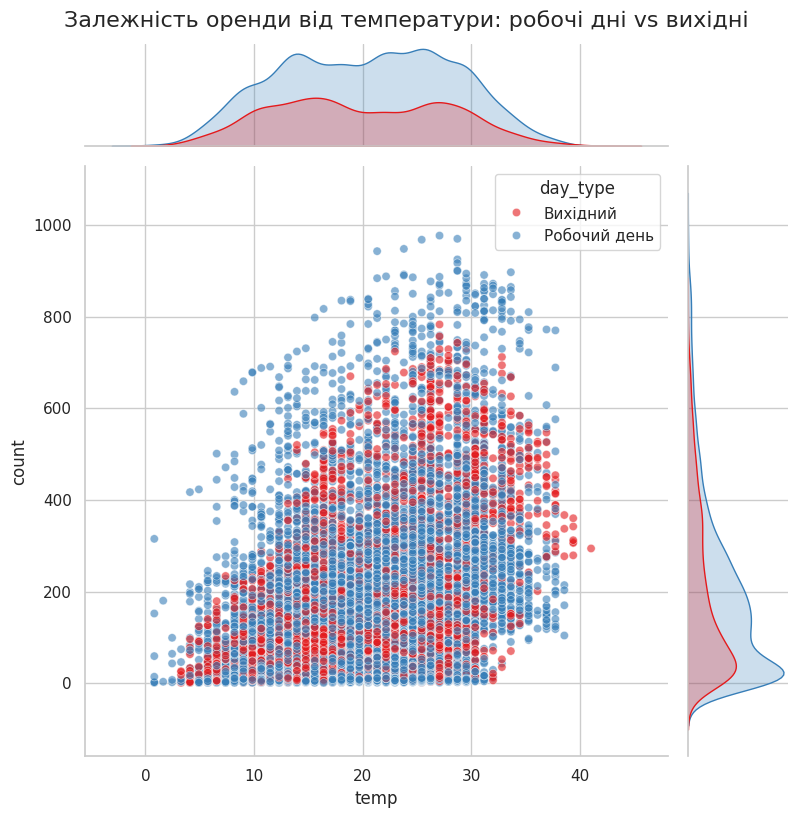

In [68]:
work_map = {0: 'Вихідний', 1: 'Робочий день'}

df['day_type'] = df['workingday'].map(work_map)

workingday_plot = sns.jointplot(
    data=df,
    x='temp',
    y='count',
    hue='day_type',
    palette='Set1',
    height=8,
    kind='scatter',
    alpha=0.6
)

workingday_plot.fig.suptitle('Залежність оренди від температури: робочі дні vs вихідні', y=1.02, fontsize=16)
plt.show()

1. Графіки вздовж осей показують розподіл щільності даних для кожної змінної:

Графік зверху показує розподіл температури (temp). Ми бачимо, що дані мають певні піки, що свідчить про те, що певні температурні діапазони зустрічаються у вибірці частіше за інші.

Графік праворуч показує розподіл кількості оренд (count). Видно, що найбільша концентрація точок (найвищий пік кривої) знаходиться в зоні низьких та середніх значень оренди.

Кольорові лінії дозволяють порівняти, чи відрізняється розподіл температури та попиту залежно від типу дня.

2. Різниця є, хоча обидві групи користувачів реагують на температуру схожим чином:

На основі центральної частини графіка видно, що в обох випадках зі зростанням температури кількість оренд має тенденцію до збільшення.

Сині точки (робочі дні) заповнюють ширший діапазон, включаючи випадки з дуже великою кількістю оренд (верхня частина графіка).

Червоні точки (вихідні) виглядають більш "стиснутими" у нижній та середній частинах графіка.

Це підтверджує, що в робочі дні обсяги оренди можуть досягати вищих значень, ніж у вихідні, що, ймовірно, пов'язано з використанням велосипедів як регулярного засобу пересування (наприклад, поїздки на роботу).

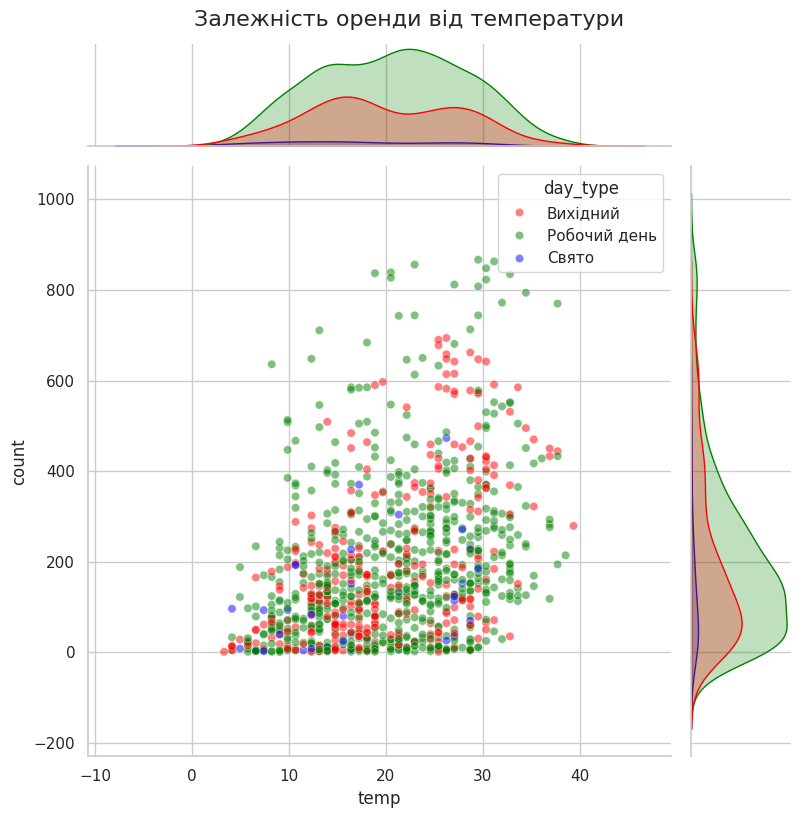

In [74]:
def categorize_day(row):
    if row['holiday'] == 1:
        return 'Свято'
    elif row['workingday'] == 1:
        return 'Робочий день'
    else:
        return 'Вихідний'

df['day_type'] = df.apply(categorize_day, axis=1)

g = sns.jointplot(
    data=df.sample(1000),
    x='temp',
    y='count',
    hue='day_type',
    palette={'Робочий день': 'green', 'Вихідний': 'red', 'Свято': 'blue'},
    height=8,
    kind='scatter',
    alpha=0.5
)

g.fig.suptitle('Залежність оренди від температури', y=1.02, fontsize=16)
plt.show()